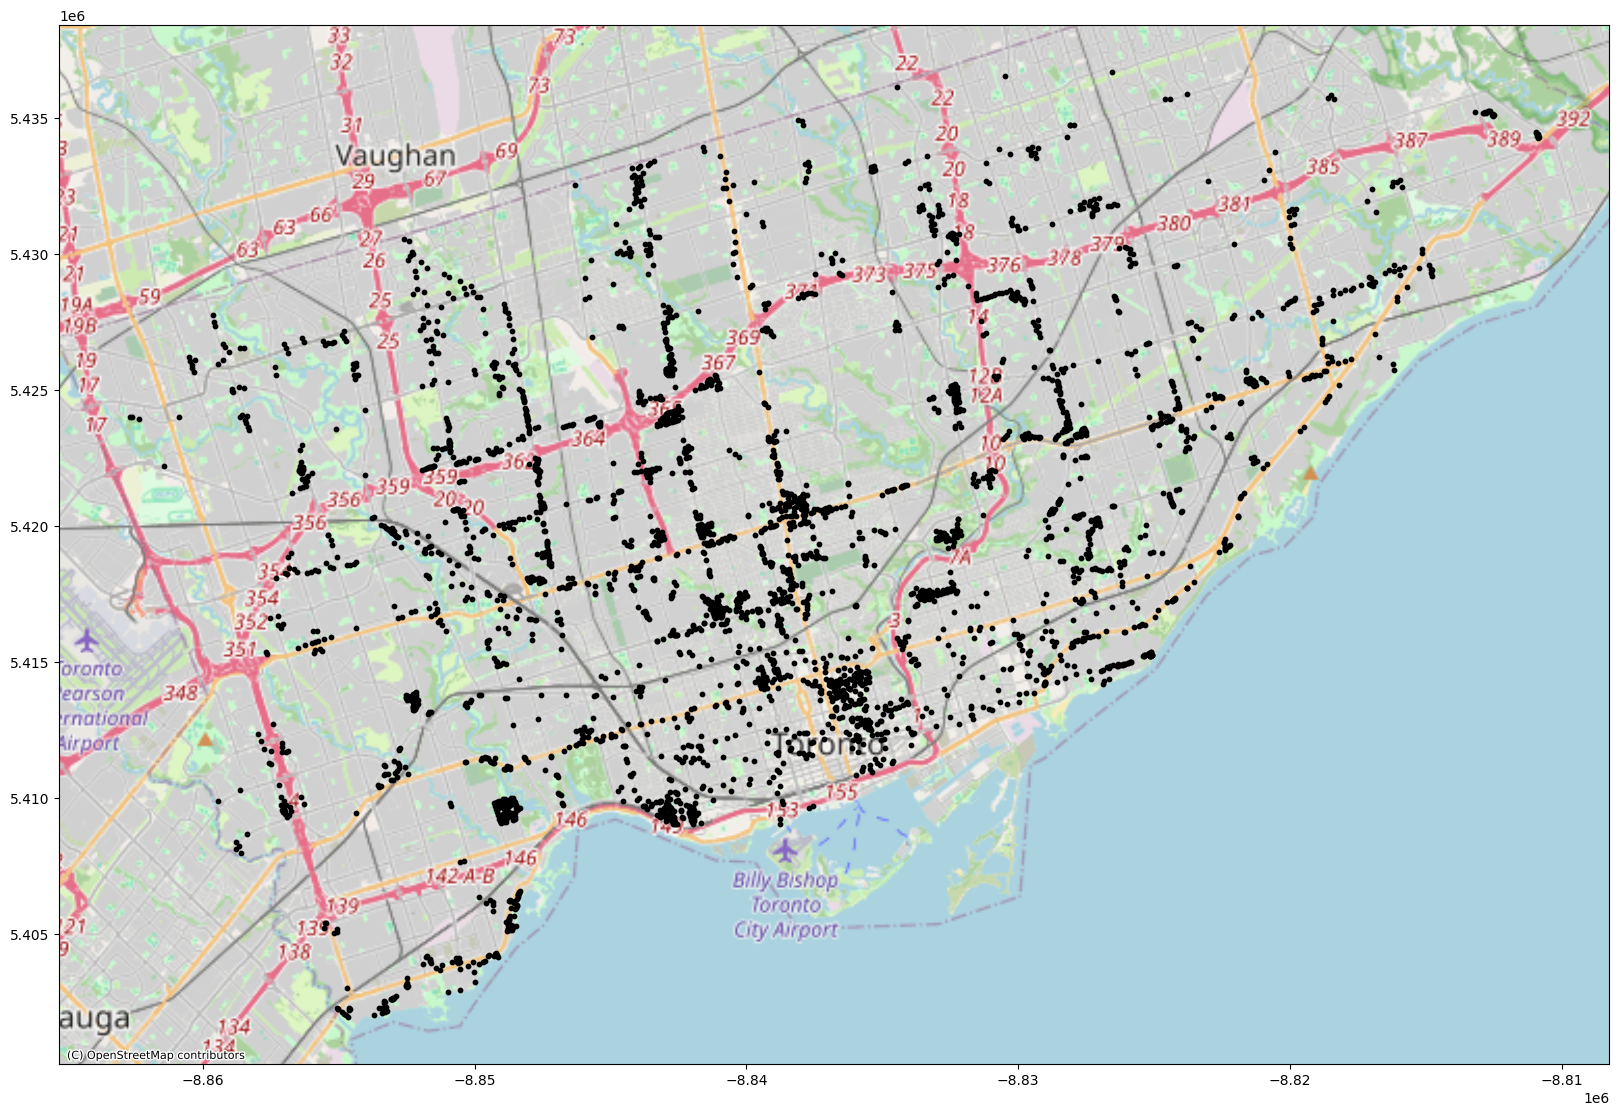

In [21]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


df = pd.read_csv("../data/02-analysis_data/analysis_data.csv")

# 1. Convert your DataFrame to a GeoDataFrame
# Longitude comes first in the (x, y) convention
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.LONGITUDE, df.LATITUDE),
    crs="EPSG:4326" # Standard coordinate system for Lat/Lon
)

# 2. Plotting (Simple)
# To get a "real" map background, we use 'explore()' (requires leafmap/folium)

# 3. Plotting with a static background (using contextily)
import contextily as ctx

ax = gdf.to_crs(epsg=3857).plot(figsize=(20, 20), color='black', markersize=10)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
# make points smaller
plt.show()

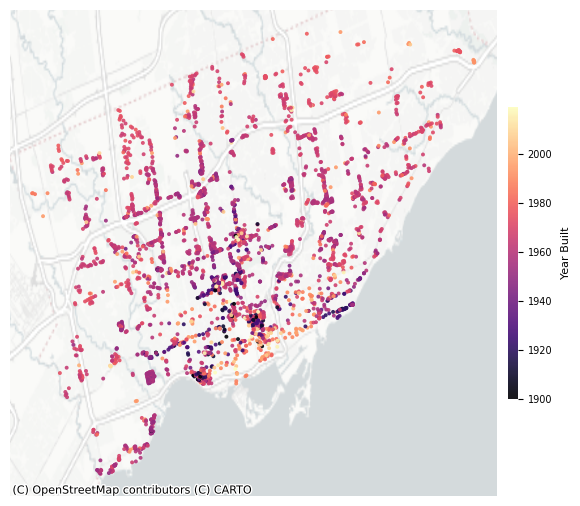

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
from io import StringIO

# Sample data

df = pd.read_csv("../data/02-analysis_data/analysis_data.csv")

import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.LONGITUDE, df.LATITUDE),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

year = gdf["YEAR_BUILT"].fillna(0).astype(int)
vmin, vmax = year.min(), year.max()
cmap = plt.cm.magma
scatter = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=year,
    cmap=cmap,
    vmin=vmin, vmax=vmax,
    s=8,
    edgecolors="none",
    alpha=0.9,
    zorder=3
)

# Basemap — light/minimal tile
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=10)

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02, aspect=30)
cbar.set_label("Year Built", fontsize=8, labelpad=6)
cbar.ax.tick_params(labelsize=7)
cbar.outline.set_visible(False)

# Clean up axes
ax.set_axis_off()

plt.tight_layout(pad=0.5)
plt.savefig("../plots/geoplot_year_built.png")
plt.show()

In [50]:
preWarDf = df[df["YEAR_BUILT"] < 1945]
postWarDf = df[(df["YEAR_BUILT"] >= 1945) & (df["YEAR_BUILT"] < 2000)]
modernDf = df[df["YEAR_BUILT"] >= 2000]

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
import os
from dotenv import load_dotenv
import geopandas as gpd

load_dotenv()  # Load environment variables from .env file

df = pd.read_csv("../data/02-analysis_data/analysis_data.csv")

def to_web_mercator(subset):
    return gpd.GeoDataFrame(
        subset,
        geometry=gpd.points_from_xy(subset.LONGITUDE, subset.LATITUDE),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

preWarDf  = df[df["YEAR_BUILT"] < 1945]
postWarDf = df[(df["YEAR_BUILT"] >= 1945) & (df["YEAR_BUILT"] < 1980)]
endOfCenturyDf = df[(df["YEAR_BUILT"] >= 1980) & (df["YEAR_BUILT"] < 2000)]
modernDf  = df[df["YEAR_BUILT"] >= 2000]

datasets = [
    (to_web_mercator(preWarDf),  "Pre-War Period (< 1945)",       "#2166ac"),
    (to_web_mercator(postWarDf), "Post-War Period (1945–1979)",    "#d6604d"),
    (to_web_mercator(endOfCenturyDf), "End of Century Period (1980–1999)", "#fdb863"),
    (to_web_mercator(modernDf),  "Modern Period (2000–)",          "#4dac26"),
]

# Shared extent — compute from full dataset so all panels show the same area
full_gdf = to_web_mercator(df)
xmin, ymin, xmax, ymax = full_gdf.total_bounds
pad_x = (xmax - xmin) * 0.04
pad_y = (ymax - ymin) * 0.04

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (gdf, title, colour) in zip(axes, datasets):
    units = gdf["CONFIRMED_UNITS"]
    bubble_size = (units / df["CONFIRMED_UNITS"].max()) * 250  # same scale across panels

    ax.scatter(
        gdf.geometry.x, gdf.geometry.y,
        s=bubble_size,
        c=colour,
        alpha=0.6,
        edgecolors="white",
        linewidths=0.3,
        zorder=3
    )
    TOKEN = os.getenv("JAWG_TOKEN")
    source =ctx.providers.Jawg.Light
    source["accessToken"] = TOKEN

    ctx.add_basemap(ax, source=source, zoom=10)

    # Lock all panels to the same extent
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(title, fontsize=9, pad=6)
    ax.set_axis_off()

# Shared size legend (units) — attach to rightmost axis
for units_val in [50, 150, 300]:
    axes[-1].scatter([], [], s=(units_val / df["CONFIRMED_UNITS"].max()) * 250,
                     c="grey", alpha=0.6, edgecolors="white", linewidths=0.3,
                     label=f"{units_val} units")
axes[-1].legend(title="Units", title_fontsize=7, fontsize=7,
                loc="lower right", frameon=False)

plt.tight_layout(pad=0.5)
plt.savefig("toronto_eras.png", dpi=300, bbox_inches="tight")
plt.show()

ModuleNotFoundError: No module named 'dotenv'

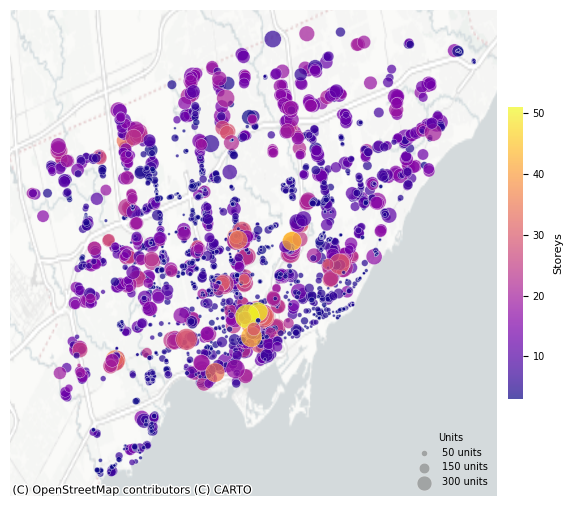

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

df = pd.read_csv("../data/02-analysis_data/analysis_data.csv")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.LONGITUDE, df.LATITUDE),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(6, 5))

storeys = gdf["CONFIRMED_STOREYS"]
units   = gdf["CONFIRMED_UNITS"]

# Scale bubble size — adjust the multiplier to taste
bubble_size = (units / units.max()) * 300

cmap = plt.cm.plasma

scatter = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=storeys,
    cmap=cmap,
    vmin=storeys.min(), vmax=storeys.max(),
    s=bubble_size,
    edgecolors="white",
    linewidths=0.3,
    alpha=0.7,          # slight transparency helps overlapping bubbles
    zorder=3
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=10)

# Colorbar for storeys
cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02, aspect=20)
cbar.set_label("Storeys", fontsize=8, labelpad=6)
cbar.ax.tick_params(labelsize=7)
cbar.outline.set_visible(False)

# Size legend for units — show a few representative values
for units_val in [50, 150, 300]:
    ax.scatter([], [], s=(units_val / units.max()) * 300,
               c="grey", alpha=0.6, edgecolors="white", linewidths=0.3,
               label=f"{units_val} units")
ax.legend(title="Units", title_fontsize=7, fontsize=7,
          loc="lower right", frameon=False)

ax.set_axis_off()
plt.tight_layout(pad=0.5)
plt.savefig("../plots/geoplot.png")
plt.show()